# Datos simulados
simulación de datos para una turbina Vesta V112-3.0MW

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
df = pd.read_csv('Datos_Tesis_CL.csv')
df.describe(include='all')

,Fecha y Hora,Generación turbina kW,"Velocidad de viento en 110.0 metros [mean,m/s]","Dirección del viento en 108.0 metros [mean,grados]","Dirección del viento en 20.0 metros [mean,grados]","Radiación Solar Global Horizontal [mean,W/m2]","Presión Atmosférica [mean,hPa]","Temperatura en 108.0 metros [mean,C]","Humedad Relativa en 108.0 metros [mean,%]",Dia Juliano
count,3072,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000
unique,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-01-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,658.309166,6.735347,169.029328,139.815744,314.626503,752.116353,16.920144,27.478479,738956.790039
std,NaN,912.828078,4.782517,101.321685,93.147545,400.387105,1.714972,3.116743,14.287604,37.142117
min,NaN,0.000000,0.171160,2.500667,1.698667,0.000000,743.573800,1.744333,4.719000,738893.000000
25%,NaN,0.000000,3.343377,109.888333,48.555417,0.000000,751.307304,15.220833,17.487917,738924.750000
50%,NaN,237.424242,5.702439,180.661417,130.208333,27.707247,752.357058,16.863333,24.508333,738957.000000
75%,NaN,902.424242,8.334376,226.266667,208.291667,683.497033,753.203017,18.929583,34.062500,738989.000000


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro

df = pd.read_csv('Datos_Tesis_CL.csv')
R = 56
A = np.pi * R**2
R_air = 287.0


a = df['Presión Atmosférica [mean,hPa]']
T = df['Temperatura en 108.0 metros [mean,C]'] + 273.15
v = df['Velocidad de viento en 110.0 metros [mean,m/s]']
p = df['Generación turbina kW'] * 1000
rho = a / (R_air * T)


# -----------------------------
# 2. Modelo Cp(λ,β)
# -----------------------------
def Cp_lambda_beta(lmbda, beta):
    lambda_i = 1 / ((1/(lmbda + 0.08*beta)) - (0.035/(beta**3 + 1)))
    Cp = 0.5176 * (116/lambda_i - 0.4*beta - 5) * np.exp(-21/lambda_i) + 0.0068*lmbda
    return Cp

def regular_pitch(viento, potencia, rho, R=56, v_rated=12, v_cutin=3, v_cut_out=25, P_nom=3_000_000):
    A = np.pi * R**2
    beta_est, omega_est = [], []

    for i in range(len(viento)):
        v = float(viento[i])
        P = float(potencia[i])
        rho_i = float(rho[i])

        best_beta, best_omega = None, None
        error_min = 1e12

        # Selección de rango de pitch según régimen de viento y potencia
        if v < v_cutin and P <= 0:
            # Rotor detenido: feathering
            pitch_range = np.linspace(85, 90, 30)
        elif v_cutin <= v < v_rated and P < P_nom:
            # Subnominal: permitir negativos para maximizar captura
            pitch_range = np.linspace(-9, 20, 30)
        elif v_rated <= v < v_cut_out and P <= P_nom:
            # Nominal: transición suave entre 0 y 20
            k = 0.5
            beta_nominal = 20 / (1 + np.exp(-k*(v - v_rated)))
            pitch_range = np.linspace(beta_nominal-2, beta_nominal+2, 20)
        else:
            # Cut-out o sobrepotencia: frenado feathering
            pitch_range = np.linspace(85, 90, 10)

        # Búsqueda de beta y omega que minimicen el error
        for beta in pitch_range:
            for omega in np.linspace(0.1, 1.85, 80):
                lmbda = (omega * R) / v if v > 0 else 0
                Cp = Cp_lambda_beta(lmbda, beta)
                P_model = 0.5 * rho_i * A * (v**3) * Cp
                error = abs(P_model - P)

                if error < error_min:
                    error_min = error
                    best_beta, best_omega = beta, omega

        # Añadir ruido gaussiano para realismo
        beta_est.append(best_beta + np.random.normal(0, 0.5))
        omega_est.append(best_omega + np.random.normal(0, 0.05))

    return np.array(beta_est), np.array(omega_est)

beta_est, omega_est = regular_pitch(v,p,rho)

C:\Users\agrom\AppData\Local\Temp\ipykernel_13016\1172989493.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  lambda_i = 1 / ((1/(lmbda + 0.08*beta)) - (0.035/(beta**3 + 1)))
C:\Users\agrom\AppData\Local\Temp\ipykernel_13016\1172989493.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  Cp = 0.5176 * (116/lambda_i - 0.4*beta - 5) * np.exp(-21/lambda_i) + 0.0068*lmbda
C:\Users\agrom\AppData\Local\Temp\ipykernel_13016\1172989493.py:24: RuntimeWarning: overflow encountered in exp
  Cp = 0.5176 * (116/lambda_i - 0.4*beta - 5) * np.exp(-21/lambda_i) + 0.0068*lmbda
C:\Users\agrom\AppData\Local\Temp\ipykernel_13016\1172989493.py:24: RuntimeWarning: overflow encountered in scalar multiply
  Cp = 0.5176 * (116/lambda_i - 0.4*beta - 5) * np.exp(-21/lambda_i) + 0.0068*lmbda
C:\Users\agrom\AppData\Local\Temp\ipykernel_13016\1172989493.py:60: RuntimeWarning: overflow encountered in scalar multiply
  P_model = 0.5 * rho_i * A * (v**3) * Cp


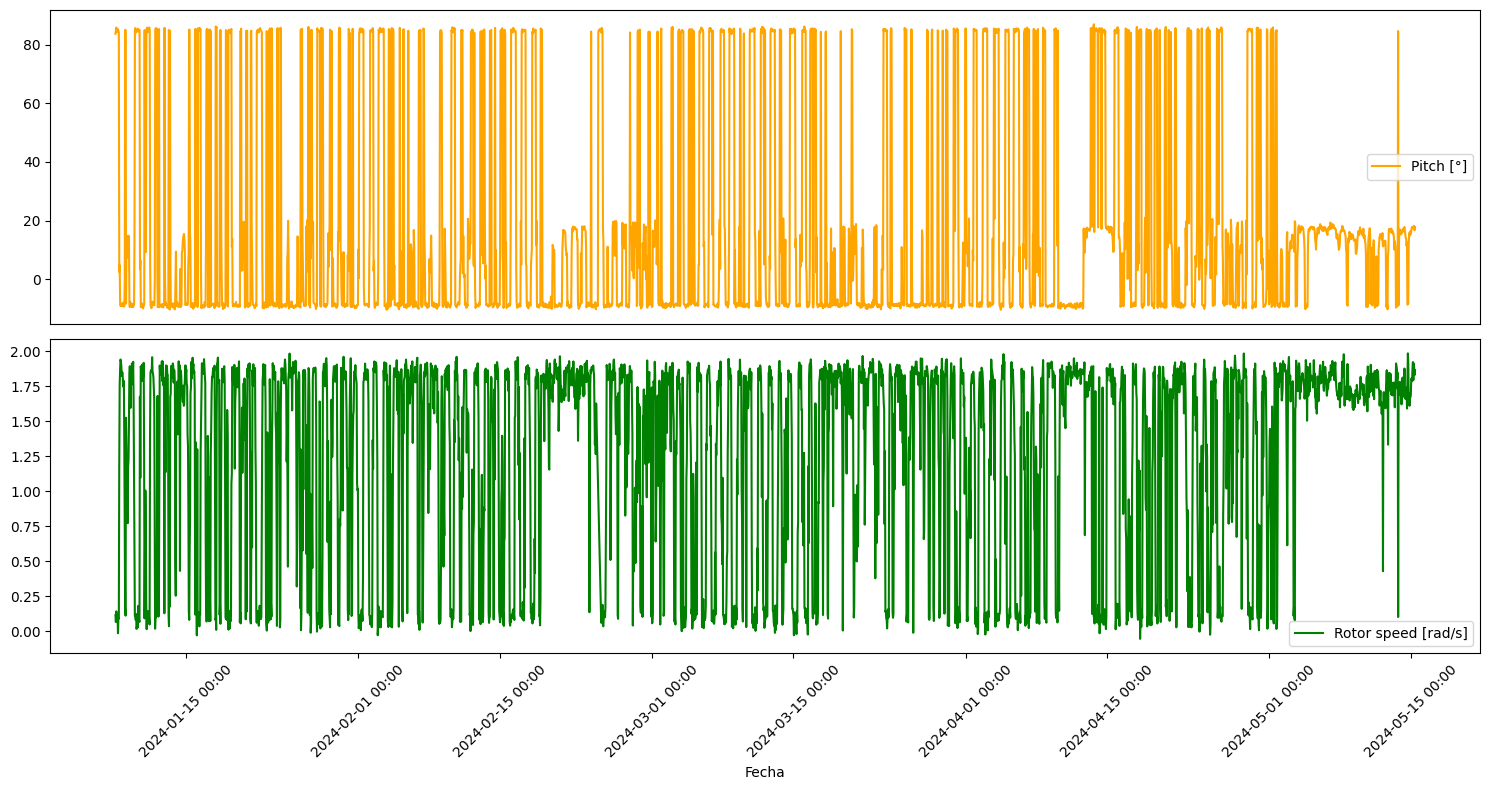

In [4]:
df['Fecha y Hora'] = pd.to_datetime(df['Fecha y Hora'])
plt.figure(figsize=(15,8))

# Primer subplot (sin fechas en el eje X)
plt.subplot(2,1,1)
plt.plot(beta_est, label="Pitch [°]", color="orange")
plt.gca().get_xaxis().set_visible(False)  # oculta el eje X
plt.legend()

# Segundo subplot (con fechas en el eje X)
plt.subplot(2,1,2)
plt.plot(df['Fecha y Hora'], omega_est, label="Rotor speed [rad/s]", color="green")
plt.legend()
plt.xlabel("Fecha")

# Formateador de fechas para que se vean más claras
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

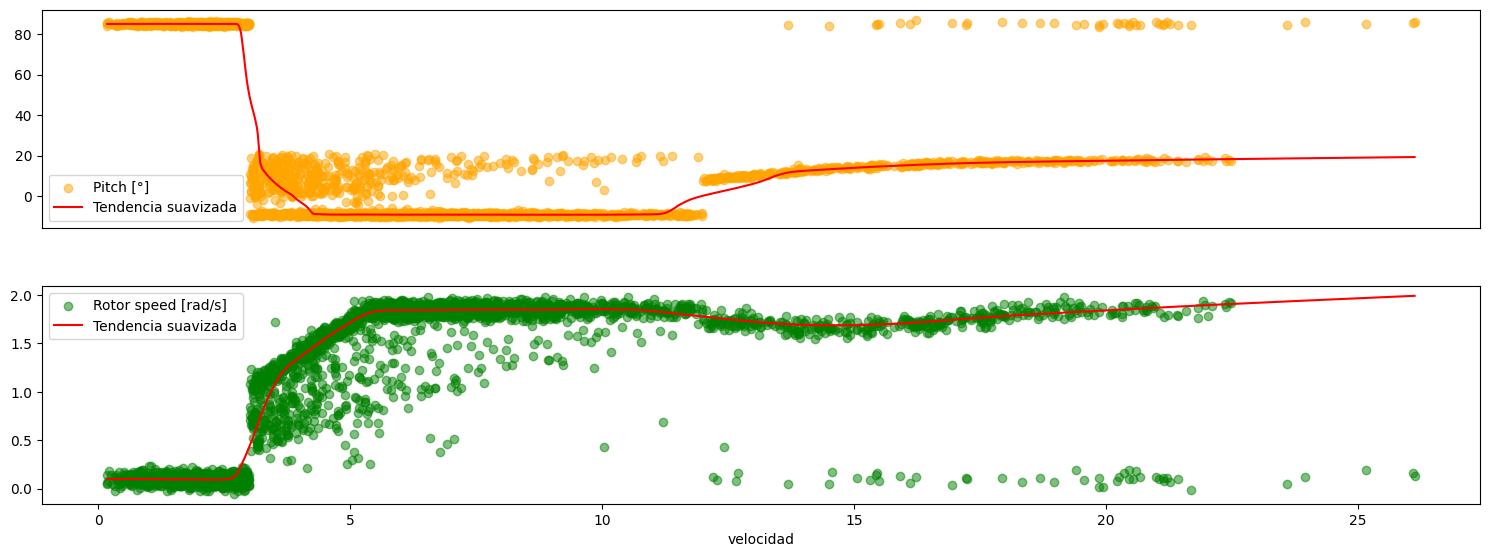

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess


plt.figure(figsize=(15,8))

# Primer subplot: Pitch vs viento
plt.subplot(3,1,1)
plt.scatter(v, beta_est, label="Pitch [°]", color="orange", alpha=0.5)
pitch_smooth = lowess(beta_est, v, frac=0.1)
plt.plot(pitch_smooth[:,0], pitch_smooth[:,1], color="red", label="Tendencia suavizada")
plt.gca().get_xaxis().set_visible(False)
plt.legend()

# Segundo subplot: Rotor speed vs viento
plt.subplot(3,1,2)
plt.scatter(v, omega_est, label="Rotor speed [rad/s]", color="green", alpha=0.5)
omega_smooth = lowess(omega_est, v, frac=0.1)
plt.plot(omega_smooth[:,0], omega_smooth[:,1], color="red", label="Tendencia suavizada")
plt.xlabel("velocidad")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df_op = pd.read_excel(r'C:\Users\agrom\OneDrive\Desktop\CodigoTesis\Predicciones_6h.xlsx', engine='openpyxl')

In [7]:
df_op.describe()

,Fecha y Hora,Velocidad Real,Velocidad Predicha
count,3066,3066.000000,3066.000000
mean,2024-03-12 09:25:40.508806,6.746864,6.928956
min,2024-01-08 06:00:00,0.171160,0.906334
25%,2024-02-09 04:15:00,3.373873,3.630745
50%,2024-03-12 13:30:00,5.707047,5.660120
75%,2024-04-13 11:45:00,8.341593,8.309821
max,2024-05-15 10:00:00,26.132913,27.370693
std,NaN,4.780077,4.717335


In [8]:
df['pitch_angle'] = beta_est
df['rotor_speed'] = omega_est

In [9]:
df.describe(include='all')

,Fecha y Hora,Generación turbina kW,"Velocidad de viento en 110.0 metros [mean,m/s]","Dirección del viento en 108.0 metros [mean,grados]","Dirección del viento en 20.0 metros [mean,grados]","Radiación Solar Global Horizontal [mean,W/m2]","Presión Atmosférica [mean,hPa]","Temperatura en 108.0 metros [mean,C]","Humedad Relativa en 108.0 metros [mean,%]",Dia Juliano,pitch_angle,rotor_speed
count,3072,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000,3072.000000
mean,2024-03-12 06:24:51.796875,658.309166,6.735347,169.029328,139.815744,314.626503,752.116353,16.920144,27.478479,738956.790039,18.373514,1.259453
min,2024-01-08 00:00:00,0.000000,0.171160,2.500667,1.698667,0.000000,743.573800,1.744333,4.719000,738893.000000,-10.518162,-0.054869
25%,2024-02-08 23:45:00,0.000000,3.343377,109.888333,48.555417,0.000000,751.307304,15.220833,17.487917,738924.750000,-8.971590,0.600232
50%,2024-03-12 10:30:00,237.424242,5.702439,180.661417,130.208333,27.707247,752.357058,16.863333,24.508333,738957.000000,-0.097491,1.667882
75%,2024-04-13 10:15:00,902.424242,8.334376,226.266667,208.291667,683.497033,753.203017,18.929583,34.062500,738989.000000,18.031163,1.832831
max,2024-05-15 10:00:00,3064.242424,26.132913,359.633333,357.500000,1264.602333,756.109917,24.306667,93.466667,739021.000000,87.064261,1.984838
std,NaN,912.828078,4.782517,101.321685,93.147545,400.387105,1.714972,3.116743,14.287604,37.142117,37.464398,0.714918


In [10]:
df.drop(columns=['Velocidad de viento en 110.0 metros [mean,m/s]', 'Dirección del viento en 108.0 metros [mean,grados]', 'Dirección del viento en 20.0 metros [mean,grados]', 'Radiación Solar Global Horizontal [mean,W/m2]', 'Presión Atmosférica [mean,hPa]', 'Temperatura en 108.0 metros [mean,C]', 'Humedad Relativa en 108.0 metros [mean,%]', 'Dia Juliano'], inplace=True)

In [11]:
df_drl = pd.merge(df, df_op, on='Fecha y Hora', how= 'outer')
df_drl.describe()

,Fecha y Hora,Generación turbina kW,pitch_angle,rotor_speed,Velocidad Real,Velocidad Predicha
count,3072,3072.000000,3072.000000,3072.000000,3066.000000,3066.000000
mean,2024-03-12 06:24:51.796875,658.309166,18.373514,1.259453,6.746864,6.928956
min,2024-01-08 00:00:00,0.000000,-10.518162,-0.054869,0.171160,0.906334
25%,2024-02-08 23:45:00,0.000000,-8.971590,0.600232,3.373873,3.630745
50%,2024-03-12 10:30:00,237.424242,-0.097491,1.667882,5.707047,5.660120
75%,2024-04-13 10:15:00,902.424242,18.031163,1.832831,8.341593,8.309821
max,2024-05-15 10:00:00,3064.242424,87.064261,1.984838,26.132913,27.370693
std,NaN,912.828078,37.464398,0.714918,4.780077,4.717335


In [12]:
df_drl.dropna(axis=0, how= 'any', subset=['Velocidad Real', 'Velocidad Predicha'], inplace=True)

In [13]:
df_drl.describe()

,Fecha y Hora,Generación turbina kW,pitch_angle,rotor_speed,Velocidad Real,Velocidad Predicha
count,3066,3066.000000,3066.000000,3066.000000,3066.000000,3066.000000
mean,2024-03-12 09:25:40.508806,659.526577,18.243228,1.261716,6.746864,6.928956
min,2024-01-08 06:00:00,0.000000,-10.518162,-0.054869,0.171160,0.906334
25%,2024-02-09 04:15:00,0.000000,-8.973434,0.617651,3.373873,3.630745
50%,2024-03-12 13:30:00,238.939394,-0.397681,1.670165,5.707047,5.660120
75%,2024-04-13 11:45:00,904.242424,17.973375,1.832913,8.341593,8.309821
max,2024-05-15 10:00:00,3064.242424,87.064261,1.984838,26.132913,27.370693
std,NaN,913.303473,37.384945,0.713781,4.780077,4.717335


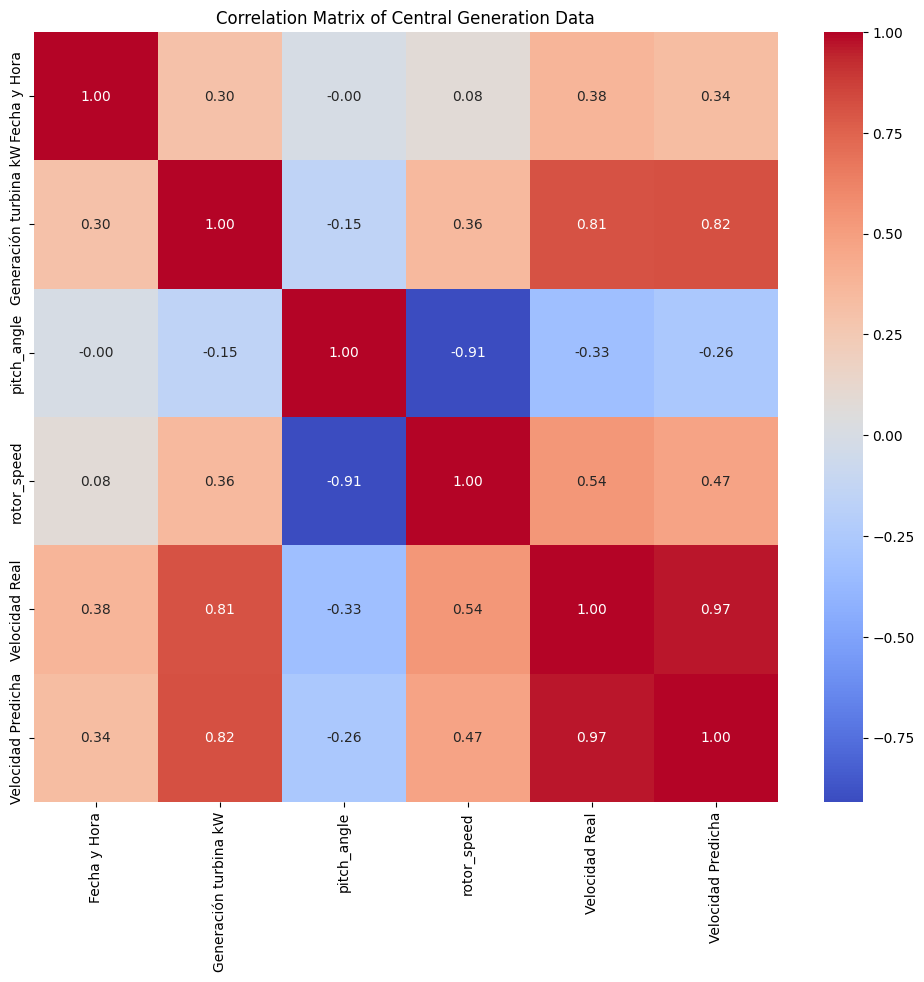

In [14]:
correlation_matrix = df_drl.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Central Generation Data')
plt.show()

In [15]:
df_drl.to_csv(r'C:\Users\agrom\OneDrive\Desktop\CodigoTesis\datos_op_CL.csv')